In [1]:
# Test script 3

In [2]:
# Plot population per decade per country

In [1]:
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da


# === Latitude weighting sum ===
def weighted_sum(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).sum(("lon", "lat"))
    return new_da

In [3]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
BMR_DIR = "/glade/work/awells/air_quality/BMR/"

pop_ssp2 = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000-2100.nc")
region_mask = xr.open_dataarray(f"{BMR_DIR}GBD_Region_Masks_0.10_popgrid.nc")

In [5]:
# Create DataArray filled with NaNs
region_population = xr.DataArray(
    np.full((len(region_mask.lat), len(region_mask.lon)), np.nan),
    coords={"lat": region_mask.lat.values, "lon": region_mask.lon.values},
    dims=["lat", "lon"]
)

# Loop over regions, add the population for each region and apply using region mask
for i in range(21):
    mask = region_mask.isel(region=i)
    pop_region = weighted_sum(xr.where(region_mask.isel(region=i) == 1, pop_ssp2, np.nan)) # population of region
    region_population = region_population.where(mask == 0, pop_region)

In [6]:
for year in [2030, 2040, 2050, 2060]:
    print(region_population.sel(year=year).max())

<xarray.DataArray ()> Size: 8B
array(1.73206579e+09)
Coordinates:
    year     int64 8B 2030
    region   <U28 112B 'Western Sub-Saharan Africa'
<xarray.DataArray ()> Size: 8B
array(1.87141718e+09)
Coordinates:
    year     int64 8B 2040
    region   <U28 112B 'Western Sub-Saharan Africa'
<xarray.DataArray ()> Size: 8B
array(1.97633301e+09)
Coordinates:
    year     int64 8B 2050
    region   <U28 112B 'Western Sub-Saharan Africa'
<xarray.DataArray ()> Size: 8B
array(2.0320827e+09)
Coordinates:
    year     int64 8B 2060
    region   <U28 112B 'Western Sub-Saharan Africa'


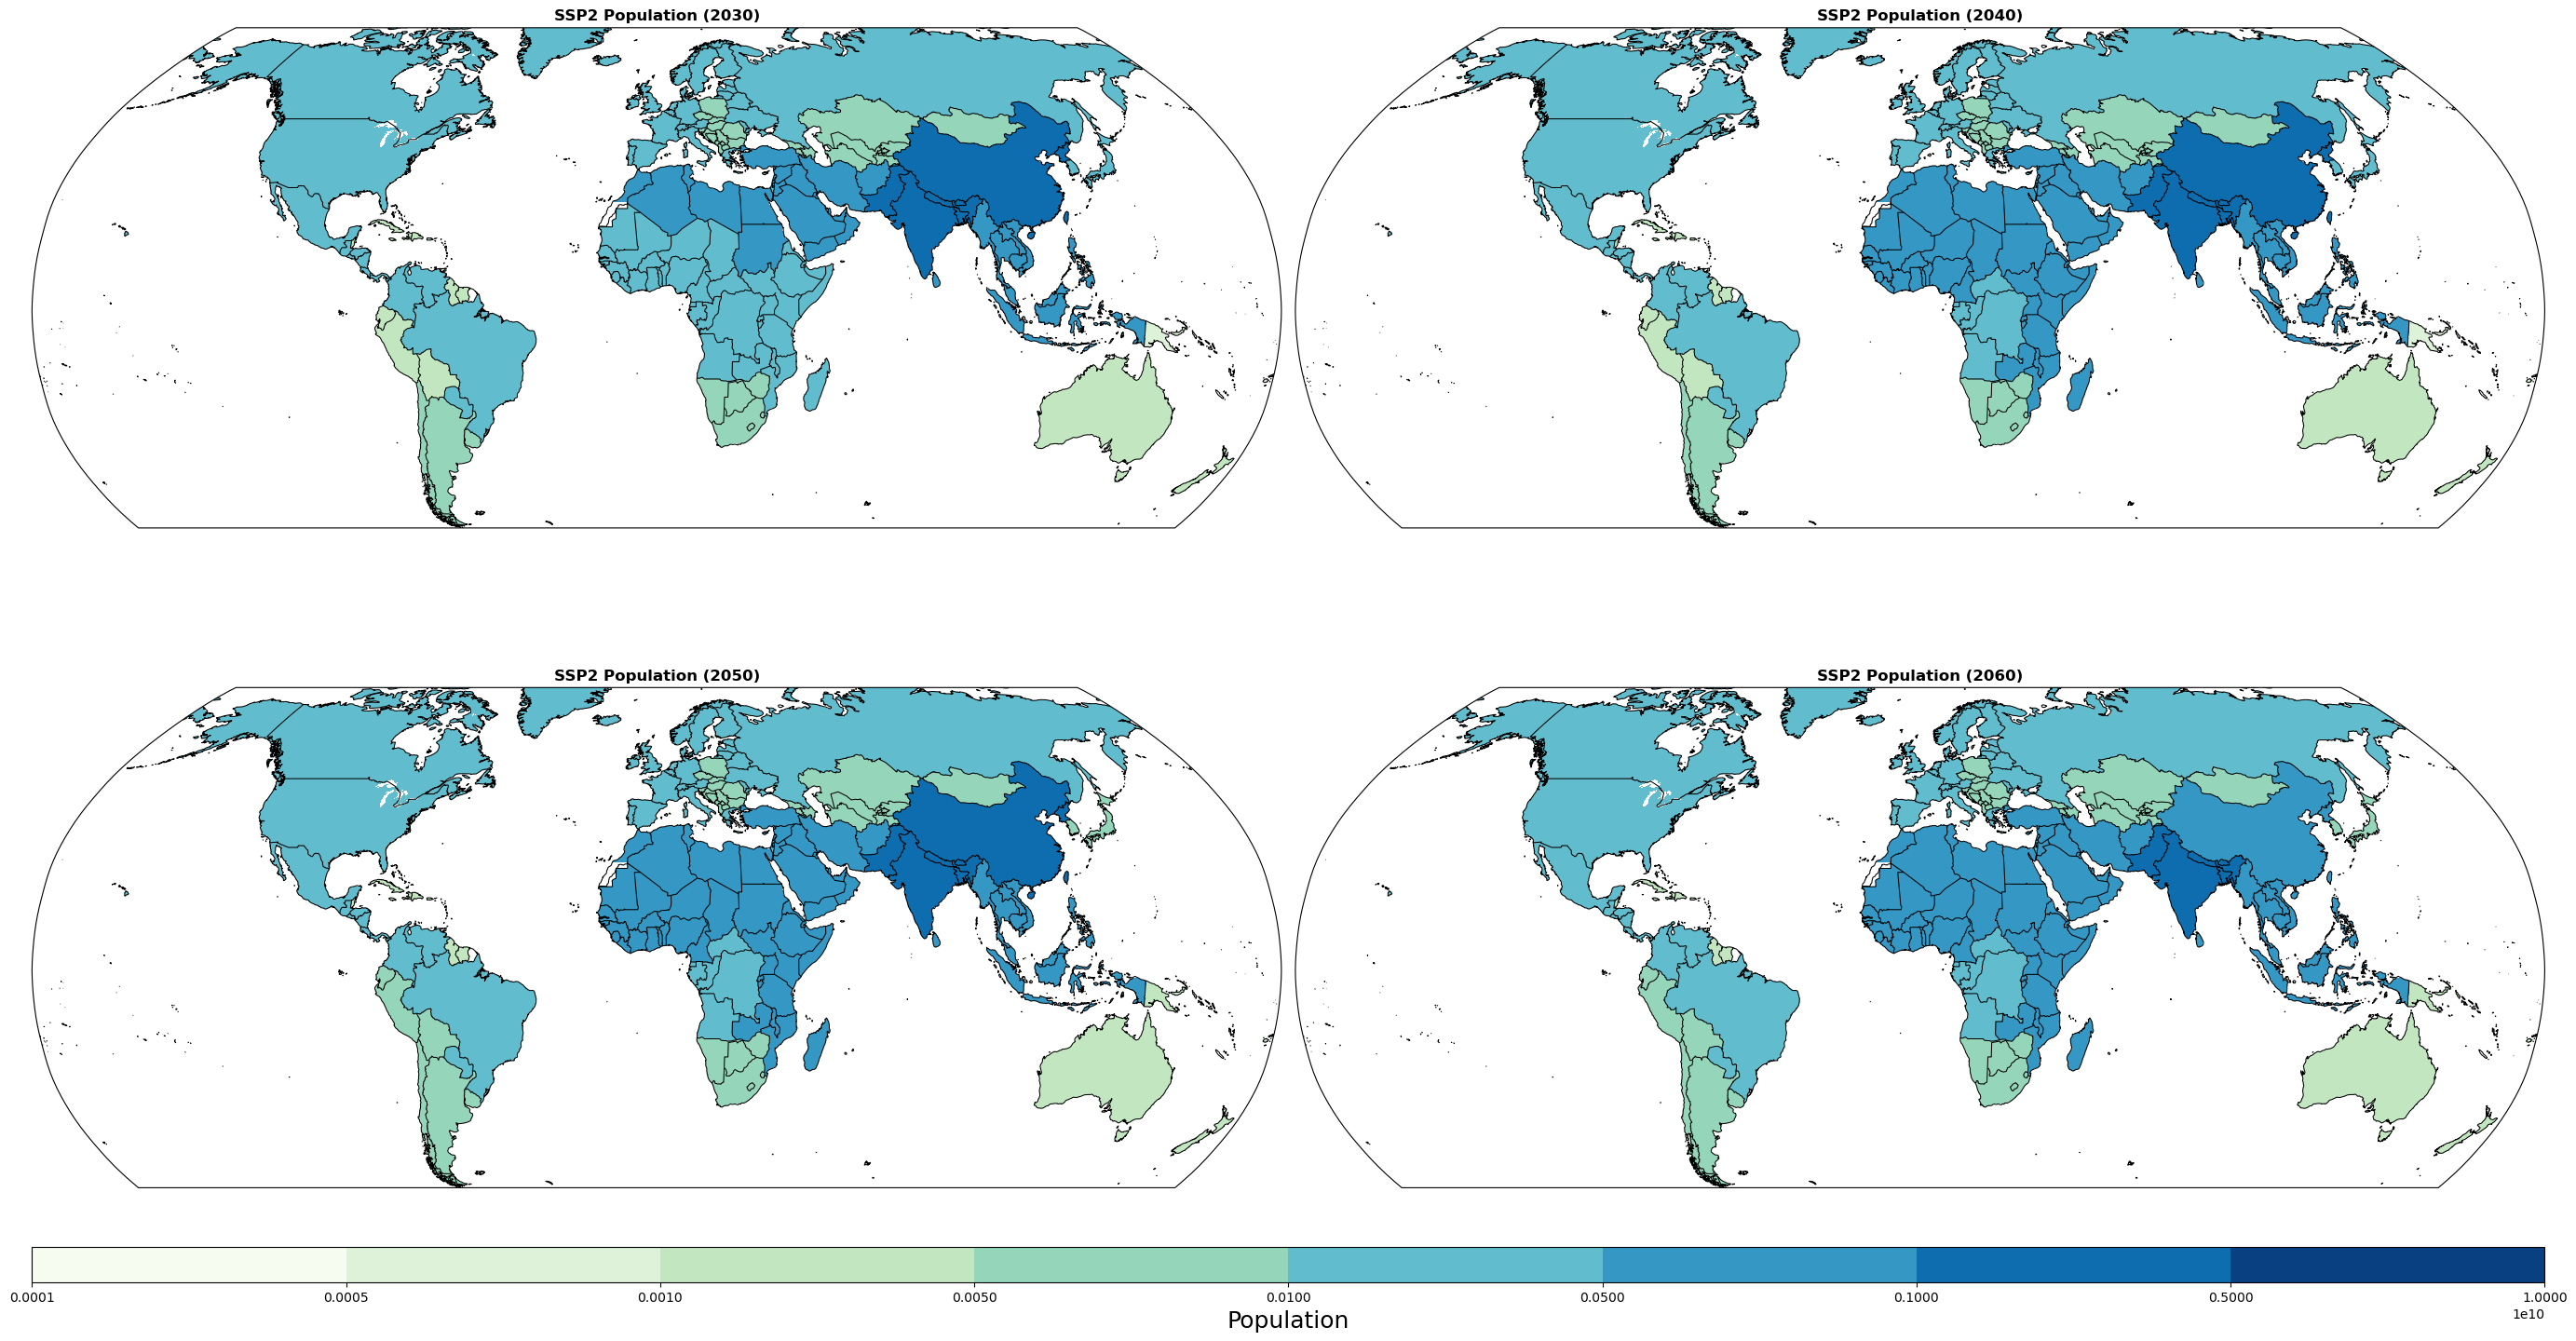

In [8]:
fig = plt.figure(figsize=autosize_figure(2, 2, scale_factor=1.6, xscale_factor=1.3))
gs = GridSpec(3, 2, height_ratios=[20, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('GnBu')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

levels = [1e6, 5e6, 1e7, 5e7, 1e8, 5e8, 1e9, 5e9, 1e10]

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(region_population).sel(year=2030).plot(transform=crs, cmap=col_map,
                                                         levels=levels, add_colorbar=False,
                                                         subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("SSP2 Population (2030)", fontweight='bold')

# Second panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = land_filter(region_population).sel(year=2040).plot(transform=crs, cmap=col_map,
                                                         levels=levels, add_colorbar=False,
                                                         subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("SSP2 Population (2040)", fontweight='bold')

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = land_filter(region_population).sel(year=2050).plot(transform=crs, cmap=col_map,
                                                         levels=levels, add_colorbar=False,
                                                         subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("SSP2 Population (2050)", fontweight='bold')

# Fourth panel
ax = fig.add_subplot(gs[1, 1], projection=projection, frameon=True)
cb = land_filter(region_population).sel(year=2060).plot(transform=crs, cmap=col_map,
                                                         levels=levels, add_colorbar=False,
                                                         subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("SSP2 Population (2060)", fontweight='bold')

# Colorbar
cax = fig.add_subplot(gs[2, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('Population', fontsize=18)

plt.tight_layout()